# 🔍 DefectVision — 02. Préparation des données pour YOLOv8

**Objectif** : Convertir MVTec AD en format YOLO (bounding boxes depuis masques de segmentation).

**Workflow** :
```
MVTec masks (.png) → Bounding boxes → Format YOLO → dataset.yaml
```

**Format YOLO** (un fichier .txt par image) :
```
class_id  x_center  y_center  width  height   (tout normalisé 0-1)
```

## 0. Setup

In [1]:
!pip install -q opencv-python-headless Pillow matplotlib numpy pyyaml

In [2]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# Chemins
MVTEC_PATH = Path('/content/drive/MyDrive/defect-vision/data/mvtec')
YOLO_PATH  = Path('/content/drive/MyDrive/defect-vision/data/yolo')
CATEGORY   = 'bottle'

print(f'✅ MVTec path : {MVTEC_PATH}')
print(f'✅ YOLO path  : {YOLO_PATH}')
print(f'✅ Catégorie  : {CATEGORY}')

Mounted at /content/drive
✅ MVTec path : /content/drive/MyDrive/defect-vision/data/mvtec
✅ YOLO path  : /content/drive/MyDrive/defect-vision/data/yolo
✅ Catégorie  : bottle


## 1. Explorer les masques disponibles

In [3]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

cat_path    = MVTEC_PATH / CATEGORY
ground_truth_path = cat_path / 'ground_truth'

# Lister les types de défauts
defect_types = sorted([d.name for d in ground_truth_path.iterdir() if d.is_dir()])
print(f'Types de défauts avec masques : {defect_types}')

# Compter les masques
for dt in defect_types:
    masks = list((ground_truth_path / dt).glob('*.png'))
    print(f'  {dt:20s} : {len(masks)} masques')

Types de défauts avec masques : ['broken_large', 'broken_small', 'contamination']
  broken_large         : 20 masques
  broken_small         : 22 masques
  contamination        : 21 masques


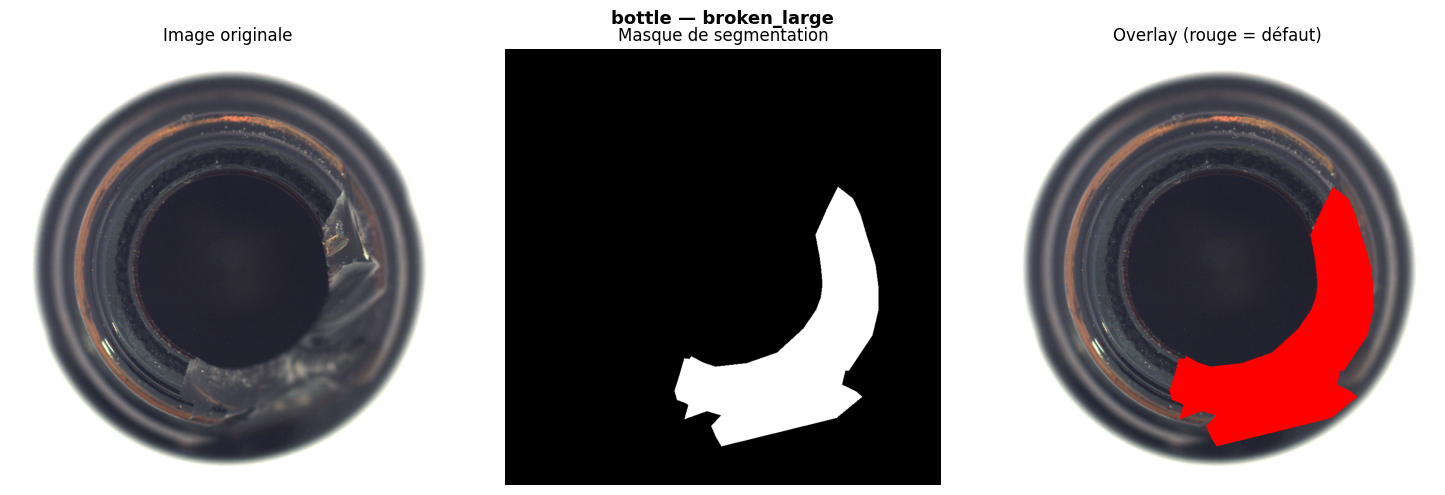

Taille image : (900, 900, 3)
Taille masque: (900, 900)


In [4]:
# Visualiser image + masque côte à côte
defect_type = defect_types[0]
masks       = sorted((ground_truth_path / defect_type).glob('*.png'))
sample_mask = masks[0]

# Image correspondante
img_name   = sample_mask.stem.replace('_mask', '') + '.png'
sample_img = cat_path / 'test' / defect_type / img_name

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'{CATEGORY} — {defect_type}', fontsize=13, fontweight='bold')

img  = np.array(Image.open(sample_img))
mask = np.array(Image.open(sample_mask))

axes[0].imshow(img)
axes[0].set_title('Image originale')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Masque de segmentation')
axes[1].axis('off')

# Overlay
overlay = img.copy()
mask_bool = mask > 127
overlay[mask_bool] = [255, 0, 0]
axes[2].imshow(overlay)
axes[2].set_title('Overlay (rouge = défaut)')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('mask_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Taille image : {img.shape}')
print(f'Taille masque: {mask.shape}')

## 2. Fonction : masque → bounding box YOLO

In [5]:
def mask_to_yolo_bbox(mask_path, img_w=900, img_h=900):
    """
    Convertit un masque de segmentation en bounding box au format YOLO.
    Retourne une liste de [x_center, y_center, width, height] normalisés.
    """
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return []

    # Binariser le masque
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Trouver les contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes = []
    for contour in contours:
        if cv2.contourArea(contour) < 50:  # Ignorer les très petits artefacts
            continue
        x, y, w, h = cv2.boundingRect(contour)

        # Normaliser en format YOLO
        x_center = (x + w / 2) / img_w
        y_center = (y + h / 2) / img_h
        w_norm   = w / img_w
        h_norm   = h / img_h

        bboxes.append([x_center, y_center, w_norm, h_norm])

    return bboxes


# Test sur le premier masque
bboxes = mask_to_yolo_bbox(sample_mask)
print(f'Masque : {sample_mask.name}')
print(f'Bounding boxes trouvées : {len(bboxes)}')
for i, bb in enumerate(bboxes):
    print(f'  bbox {i+1} : x_c={bb[0]:.4f}  y_c={bb[1]:.4f}  w={bb[2]:.4f}  h={bb[3]:.4f}')

Masque : 000_mask.png
Bounding boxes trouvées : 1
  bbox 1 : x_c=0.6228  y_c=0.6133  w=0.4678  h=0.5956


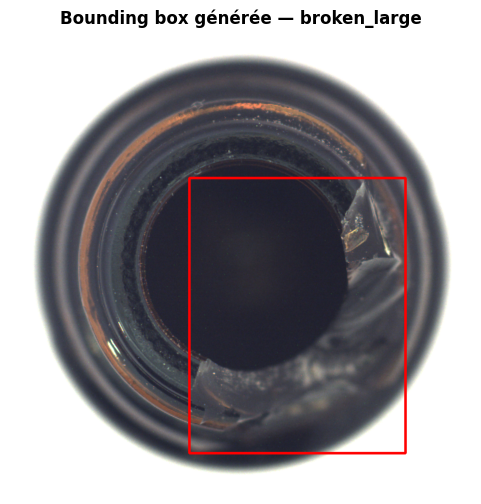

In [6]:
# Visualiser la bounding box sur l'image
def visualize_bbox(img_path, bboxes, img_w=900, img_h=900):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for bb in bboxes:
        x_c, y_c, w_n, h_n = bb
        x = int((x_c - w_n / 2) * img_w)
        y = int((y_c - h_n / 2) * img_h)
        w = int(w_n * img_w)
        h = int(h_n * img_h)
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 3)

    return img

viz = visualize_bbox(sample_img, bboxes)
plt.figure(figsize=(6, 6))
plt.imshow(viz)
plt.title(f'Bounding box générée — {defect_type}', fontweight='bold')
plt.axis('off')
plt.savefig('bbox_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Construire le dataset YOLO complet

In [7]:
import shutil
import random

random.seed(42)

# Classes YOLO : 0 = good, 1 = defect
CLASS_DEFECT = 0  # Une seule classe : defect

# Créer la structure de dossiers YOLO
for split in ['train', 'val', 'test']:
    (YOLO_PATH / CATEGORY / split / 'images').mkdir(parents=True, exist_ok=True)
    (YOLO_PATH / CATEGORY / split / 'labels').mkdir(parents=True, exist_ok=True)

print('✅ Structure YOLO créée :')
print(f'  {YOLO_PATH}/{CATEGORY}/')
print('  ├── train/images  & train/labels')
print('  ├── val/images    & val/labels')
print('  └── test/images   & test/labels')

✅ Structure YOLO créée :
  /content/drive/MyDrive/defect-vision/data/yolo/bottle/
  ├── train/images  & train/labels
  ├── val/images    & val/labels
  └── test/images   & test/labels


In [8]:
def copy_image_and_label(img_path, label_path, dest_split, bboxes=None, class_id=0):
    """Copie une image et crée son fichier label YOLO."""
    # Copier l'image
    dest_img = YOLO_PATH / CATEGORY / dest_split / 'images' / img_path.name
    shutil.copy2(img_path, dest_img)

    # Créer le fichier label
    dest_lbl = YOLO_PATH / CATEGORY / dest_split / 'labels' / (img_path.stem + '.txt')
    with open(dest_lbl, 'w') as f:
        if bboxes:
            for bb in bboxes:
                f.write(f"{class_id} {bb[0]:.6f} {bb[1]:.6f} {bb[2]:.6f} {bb[3]:.6f}\n")
        # Si pas de bbox (image good) → fichier vide = pas de défaut

stats = {'train': 0, 'val': 0, 'test': 0}

# --- Images defect (test set MVTec) → 70% test, 20% val, 10% train ---
all_defect_imgs = []
for dt in defect_types:
    imgs = sorted((cat_path / 'test' / dt).glob('*.png'))
    for img in imgs:
        mask = ground_truth_path / dt / (img.stem + '_mask.png')
        all_defect_imgs.append((img, mask, dt))

random.shuffle(all_defect_imgs)
n = len(all_defect_imgs)
n_test  = int(n * 0.70)
n_val   = int(n * 0.20)
n_train = n - n_test - n_val

splits_defect = (
    [('train', x) for x in all_defect_imgs[:n_train]] +
    [('val',   x) for x in all_defect_imgs[n_train:n_train+n_val]] +
    [('test',  x) for x in all_defect_imgs[n_train+n_val:]]
)

for split, (img_path, mask_path, _) in splits_defect:
    bboxes = mask_to_yolo_bbox(mask_path)
    copy_image_and_label(img_path, mask_path, split, bboxes, CLASS_DEFECT)
    stats[split] += 1

# --- Images good (train MVTec) → 80% train, 20% val ---
good_imgs = sorted((cat_path / 'train' / 'good').glob('*.png'))
random.shuffle(good_imgs)
n_good_val   = int(len(good_imgs) * 0.20)
n_good_train = len(good_imgs) - n_good_val

for img_path in good_imgs[:n_good_train]:
    copy_image_and_label(img_path, None, 'train', bboxes=None)
    stats['train'] += 1

for img_path in good_imgs[n_good_train:]:
    copy_image_and_label(img_path, None, 'val', bboxes=None)
    stats['val'] += 1

print('✅ Dataset YOLO construit :')
print(f'  Train : {stats["train"]} images')
print(f'  Val   : {stats["val"]} images')
print(f'  Test  : {stats["test"]} images')
print(f'  Total : {sum(stats.values())} images')

✅ Dataset YOLO construit :
  Train : 175 images
  Val   : 53 images
  Test  : 44 images
  Total : 272 images


## 4. Générer dataset.yaml

In [9]:
import yaml

dataset_yaml = {
    'path'  : str(YOLO_PATH / CATEGORY),
    'train' : 'train/images',
    'val'   : 'val/images',
    'test'  : 'test/images',
    'nc'    : 1,
    'names' : ['defect']
}

yaml_path = YOLO_PATH / CATEGORY / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('✅ dataset.yaml généré :')
print()
with open(yaml_path) as f:
    print(f.read())

✅ dataset.yaml généré :

names:
- defect
nc: 1
path: /content/drive/MyDrive/defect-vision/data/yolo/bottle
test: test/images
train: train/images
val: val/images



## 5. Vérification visuelle

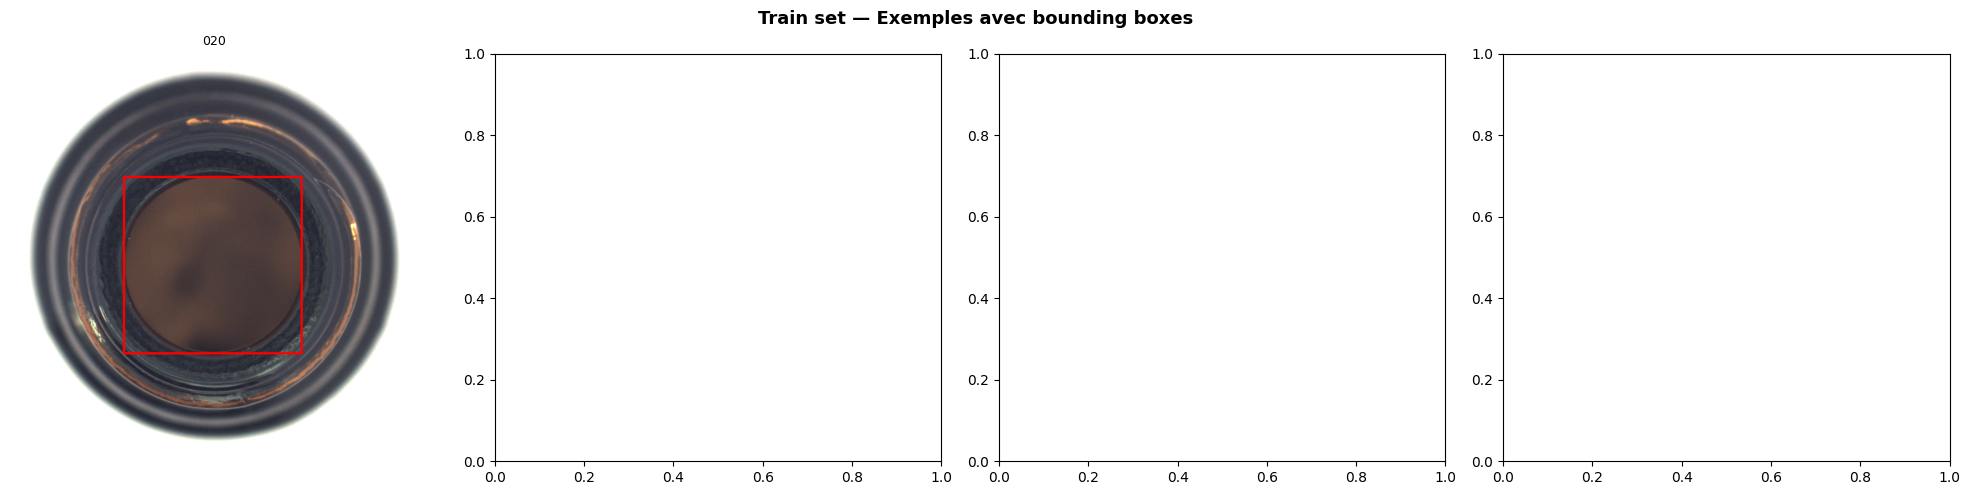

✅ Vérification visuelle OK


In [10]:
# Vérifier quelques exemples du train set
train_imgs = sorted((YOLO_PATH / CATEGORY / 'train' / 'images').glob('*.png'))
train_lbls = sorted((YOLO_PATH / CATEGORY / 'train' / 'labels').glob('*.txt'))

# Prendre 4 images avec défauts
defect_examples = []
for lbl_path in train_lbls:
    with open(lbl_path) as f:
        content = f.read().strip()
    if content:  # fichier non vide = défaut
        img_path = YOLO_PATH / CATEGORY / 'train' / 'images' / (lbl_path.stem + '.png')
        defect_examples.append((img_path, lbl_path))
    if len(defect_examples) == 4:
        break

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Train set — Exemples avec bounding boxes', fontsize=13, fontweight='bold')

for ax, (img_path, lbl_path) in zip(axes, defect_examples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            _, xc, yc, wn, hn = map(float, parts)
            x = int((xc - wn/2) * w)
            y = int((yc - hn/2) * h)
            bw = int(wn * w)
            bh = int(hn * h)
            cv2.rectangle(img, (x, y), (x+bw, y+bh), (255, 0, 0), 3)

    ax.imshow(img)
    ax.set_title(img_path.stem[:15], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('yolo_train_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Vérification visuelle OK')

## ✅ Résumé

| Info | Valeur |
|------|--------|
| Format | YOLO (bboxes normalisées) |
| Classe | 1 (defect) |
| Stockage | Google Drive `/defect-vision/data/yolo/bottle` |
| Fichier config | `dataset.yaml` |
| Prochain notebook | `03_yolov8_training.ipynb` |

**Prochaine étape** : Entraîner YOLOv8 sur ce dataset.